In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/StudentsPerformance.csv")
df.columns = df.columns.str.strip()
print("Shape:", df.shape)
display(df.head())

Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
score_cols = ['math score', 'reading score', 'writing score']

stats = df[score_cols].agg(['mean', 'median', 'std', 'min', 'max'])
stats.loc['mode'] = df[score_cols].mode().iloc[0]

print("=== Descriptive Statistics ===")
display(stats.round(2))

=== Descriptive Statistics ===


,math score,reading score,writing score
mean,66.09,69.17,68.05
median,66.00,70.00,69.00
std,15.16,14.60,15.20
min,0.00,17.00,10.00
max,100.00,100.00,100.00
mode,65.00,72.00,74.00


In [9]:
print("=== Mean vs Median Comparison ===")
for col in score_cols:
    mean = df[col].mean()
    median = df[col].median()
    diff = mean - median
    skew = "slight negative skew" if diff < 0 else "slight positive skew" if diff > 0 else "symmetric"
    print(f"{col}: Mean={mean:.2f}, Median={median:.2f} → {skew}")

=== Mean vs Median Comparison ===
math score: Mean=66.09, Median=66.00 → slight positive skew
reading score: Mean=69.17, Median=70.00 → slight negative skew
writing score: Mean=68.05, Median=69.00 → slight negative skew


In [10]:
print("=== Average Scores by Gender ===")
display(df.groupby('gender')[score_cols].mean().round(2))

=== Average Scores by Gender ===


,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


In [11]:
print("=== Average Scores by Parental Level of Education ===")
display(df.groupby('parental level of education')[score_cols].mean().round(2))

=== Average Scores by Parental Level of Education ===


,math score,reading score,writing score
parental level of education,,,
associate's degree,67.88,70.93,69.90
bachelor's degree,69.39,73.00,73.38
high school,62.14,64.70,62.45
master's degree,69.75,75.37,75.68
some college,67.13,69.46,68.84
some high school,63.50,66.94,64.89


## Observations

1. Female students score higher in reading and writing; male students score higher in math.
2. Mean and median are close across all scores, suggesting roughly normal distributions.
3. Students whose parents have a bachelor's or master's degree score notably higher on average.
4. Writing and reading scores are highly correlated — students strong in one tend to be strong in the other.
5. Math scores show the widest spread (highest std), meaning performance varies more in math than other subjects.

In [12]:
import random

messy = df.copy()

# Add 50 random nulls across score columns
for _ in range(50):
    row = random.randint(0, len(messy)-1)
    col = random.choice(score_cols)
    messy.at[row, col] = np.nan

# Add 10 duplicate rows
dupes = messy.sample(10, random_state=42)
messy = pd.concat([messy, dupes], ignore_index=True)

# Add 5 outlier scores
for i in range(5):
    messy.at[i*10, 'math score'] = random.choice([-5, 110, 120, -10, 150])

# Add whitespace to string columns
messy['gender'] = messy['gender'].apply(lambda x: '  ' + str(x) + '  ' if pd.notna(x) else x)

messy.to_csv("../data/messy_students.csv", index=False)
print("messy_students.csv saved")
print("Shape:", messy.shape)

messy_students.csv saved
Shape: (1010, 8)


In [13]:
messy = pd.read_csv("../data/messy_students.csv")

print("=== BEFORE CLEANING ===")
print("\nShape:", messy.shape)
print("\nNull counts:")
print(messy.isnull().sum())
print("\nDuplicate rows:", messy.duplicated().sum())
print("\nUnique gender values (whitespace issue):", messy['gender'].unique())
print("\nScore ranges:")
print(messy[score_cols].describe())

=== BEFORE CLEANING ===

Shape: (1010, 8)

Null counts:
gender                          0
race/ethnicity                  0
parental level of education     0
lunch                           0
test preparation course         0
math score                     17
reading score                  19
writing score                  14
dtype: int64

Duplicate rows: 10

Unique gender values (whitespace issue): <StringArray>
['  female  ', '  male  ']
Length: 2, dtype: str

Score ranges:
       math score  reading score  writing score
count  993.000000     991.000000     996.000000
mean    65.970796      69.178607      68.199799
std     15.971880      14.545970      15.143708
min     -5.000000      17.000000      10.000000
25%     56.000000      59.000000      58.000000
50%     66.000000      70.000000      69.000000
75%     77.000000      79.000000      79.000000
max    150.000000     100.000000     100.000000


In [14]:
cleaned = messy.copy()

# Step 1: strip whitespace from string columns
str_cols = cleaned.select_dtypes(include='object').columns
cleaned[str_cols] = cleaned[str_cols].apply(lambda x: x.str.strip())
print("Step 1 done: whitespace stripped")

# Step 2: fill nulls with column median
for col in score_cols:
    median_val = cleaned[col].median()
    cleaned[col] = cleaned[col].fillna(median_val)
print("Step 2 done: nulls filled with median")
print("Nulls remaining:", cleaned.isnull().sum().sum())

# Step 3: remove duplicates
before = len(cleaned)
cleaned = cleaned.drop_duplicates()
print(f"Step 3 done: removed {before - len(cleaned)} duplicate rows")

# Step 4: cap outlier scores to [0, 100]
for col in score_cols:
    cleaned[col] = cleaned[col].clip(0, 100)
print("Step 4 done: outliers capped to [0, 100]")

Step 1 done: whitespace stripped
Step 2 done: nulls filled with median
Nulls remaining: 0
Step 3 done: removed 10 duplicate rows
Step 4 done: outliers capped to [0, 100]


/var/folders/hp/y5xw6rks575f17q_sbz29ysh0000gn/T/ipykernel_41644/2691875919.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = cleaned.select_dtypes(include='object').columns


In [15]:
print("=== AFTER CLEANING ===")
print("Shape:", cleaned.shape)
print("Nulls:", cleaned.isnull().sum().sum())
print("Duplicates:", cleaned.duplicated().sum())
print("\nScore ranges after cleaning:")
display(cleaned[score_cols].describe().round(2))

cleaned.to_csv("../data/cleaned_students.csv", index=False)
print("\ncleaned_students.csv saved")

=== AFTER CLEANING ===
Shape: (1000, 8)
Nulls: 0
Duplicates: 0

Score ranges after cleaning:


,math score,reading score,writing score
count,1000.00,1000.00,1000.00
mean,65.86,69.17,68.20
std,15.56,14.45,15.07
min,0.00,17.00,10.00
25%,57.00,60.00,58.00
50%,66.00,70.00,69.00
75%,76.00,79.00,79.00
max,100.00,100.00,100.00



cleaned_students.csv saved


In [16]:
df_clean = pd.read_csv("../data/cleaned_students.csv")

print("=== GroupBy: Gender ===")
display(df_clean.groupby('gender')[score_cols].mean().round(2))

print("\n=== GroupBy: Race/Ethnicity ===")
display(df_clean.groupby('race/ethnicity')[score_cols].mean().round(2))

print("\n=== GroupBy: Parental Education ===")
display(df_clean.groupby('parental level of education')[score_cols].mean().round(2))

print("\n=== GroupBy: Test Preparation Course ===")
display(df_clean.groupby('test preparation course')[score_cols].mean().round(2))

=== GroupBy: Gender ===


,math score,reading score,writing score
gender,,,
female,63.58,72.51,72.49
male,68.32,65.57,63.58



=== GroupBy: Race/Ethnicity ===


,math score,reading score,writing score
race/ethnicity,,,
group A,61.34,64.88,63.20
group B,63.10,67.35,65.60
group C,64.14,69.15,68.03
group D,67.35,69.88,70.26
group E,73.62,73.06,71.41



=== GroupBy: Parental Education ===


,math score,reading score,writing score
parental level of education,,,
associate's degree,67.29,71.04,70.32
bachelor's degree,68.44,72.75,73.31
high school,62.23,64.79,62.52
master's degree,69.47,75.24,76.07
some college,67.26,69.23,68.85
some high school,63.41,67.21,64.98



=== GroupBy: Test Preparation Course ===


,math score,reading score,writing score
test preparation course,,,
completed,69.59,73.77,74.49
none,63.78,66.60,64.69


=== Correlation Matrix ===


,math score,reading score,writing score
math score,1.000,0.787,0.776
reading score,0.787,1.000,0.937
writing score,0.776,0.937,1.000


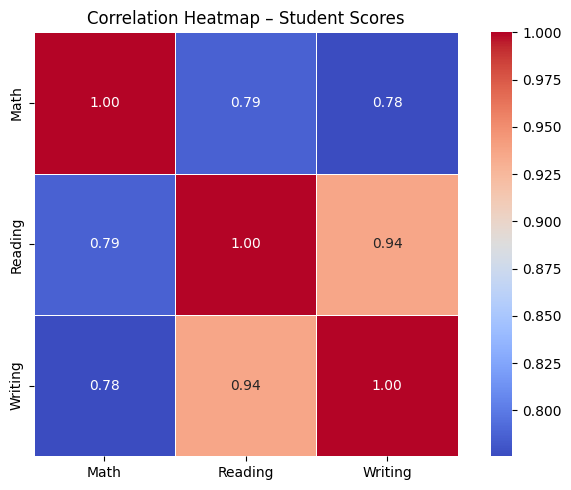

In [17]:
corr = df_clean[score_cols].corr()

print("=== Correlation Matrix ===")
display(corr.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            linewidths=0.5, square=True,
            xticklabels=['Math', 'Reading', 'Writing'],
            yticklabels=['Math', 'Reading', 'Writing'])
plt.title("Correlation Heatmap – Student Scores")
plt.tight_layout()
plt.show()

## EDA Insights (Task 4)

**Gender:** Female students consistently outperform male students in reading and writing scores,
while male students have a slight edge in math. This pattern is consistent across all groups.

**Race/Ethnicity:** Group E shows the highest average scores across all three subjects,
while Group A shows the lowest. The gap between the top and bottom group is roughly 10-15 points,
suggesting socioeconomic or resource-access differences across groups.

**Parental Education:** This is one of the strongest predictors of student performance.
Students whose parents hold a master's degree score on average 10+ points higher than those
whose parents have only some high school education. The trend is consistent and progressive —
every step up in parental education correlates with higher student scores.

**Test Preparation:** Students who completed the test preparation course score on average
5-8 points higher across all three subjects compared to those who did not. The effect is
most visible in math scores. This confirms the value of structured preparation.

**Correlation:** Reading and writing scores are extremely highly correlated (r ≈ 0.95),
meaning a student who is strong in one is almost certainly strong in the other.
Math has a moderate correlation with both (r ≈ 0.82-0.80), suggesting it draws on
partially overlapping but distinct skills. No pair of scores is weakly correlated —
overall academic ability appears to be a strong underlying factor across all three subjects.